In [2]:
import numpy as np
import math
import pygad
import statistics
import pandas as pd
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, mean_squared_error
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import time
import warnings
warnings.filterwarnings("ignore")

In [3]:
def yes_function(x, y, a, kappa, lam, gamma=1):
    return 1 - np.maximum(0.0, ((1-x)**kappa + (1-y)**kappa - (1-a)**kappa))**(1/kappa)

def no_function(x, y, a, kappa, lam, gamma=1):
    return np.maximum(0.0, (x**lam + y**lam - a**lam))**(1/lam)

def maybe_function(x, y, a, kappa, lam, gamma=1):
    if x is None or y is None:
        return 0
    if gamma == 0:
        return 0
    else:
        value = gamma*(1/a)*x*y + (1-gamma)*(1 - (1/(1-a))*(1-x)*(1-y))
    return statistics.median([0, 1, value])

def classification(x, y, a, kappa, lam, gamma):
    if x < a and y < a:
        return no_function(x, y, a, 1, lam, 1)
    elif x > a and y > a:
        return yes_function(x, y, a, kappa, 1, 1)
    else:
        return maybe_function(x, y, a, 1, 1, gamma)

def classification_vec(values, diffs, a, kappa, lam, gamma):
    if values.size == 0 or diffs.size == 0:
        return np.zeros_like(values)

    results = np.zeros_like(values)
    mask_no = (values < a) & (diffs < a)
    mask_yes = (values > a) & (diffs > a)
    mask_maybe = ~(mask_no | mask_yes)

    if np.any(mask_no):
        results[mask_no] = no_function(values[mask_no], diffs[mask_no], a, 1, lam, 1)
    if np.any(mask_yes):
        results[mask_yes] = yes_function(values[mask_yes], diffs[mask_yes], a, kappa, 1, 1)
    if np.any(mask_maybe):
        for idx in np.where(mask_maybe)[0]:
            results[idx] = maybe_function(values[idx], diffs[idx], a, 1, 1, gamma)

    return np.round(results, 4)

def evaluate_params(X, y, params):
    n_features = X.shape[1]
    value = np.abs(X[:, 0] - params[5])
    i = 6
    for j in range(n_features - 1):
        diff = np.abs(X[:, j+1] - params[i])
        value = classification_vec(value, diff,
                                   params[0], params[1], params[2], params[3])
        i += 1

    error = np.exp2(np.abs(value - y))
    calc_class = (value >= params[0]).astype(int)
    target_class = (y >= params[0]).astype(int)
    mean_error = np.mean(error)
    f1 = f1_score(target_class, calc_class, zero_division=0)

    return value, error, calc_class, target_class, mean_error, f1

def run_ga_on_fold(X_train_fold, y_train_fold):
    n_features = X_train_fold.shape[1]

    def fitness_func(ga_instance, solution, solution_idx):
        try:
            param = np.array(solution, dtype=float)
            value = np.abs(X_train_fold[:, 0] - param[5])
            i = 6
            for j in range(n_features - 1):
                diff = np.abs(X_train_fold[:, j+1] - param[i])
                value = classification_vec(value, diff,
                                           param[0], param[1], param[2], param[3])
                i += 1

            error = np.exp2(np.abs(value - y_train_fold))
            fitness1 = 1.0 / (math.sqrt(np.mean(error)) + 1e-8)

            calc_class = (value >= param[0]).astype(int)
            target_class = (y_train_fold >= param[0]).astype(int)
            fitness2 = f1_score(target_class, calc_class, zero_division=0)

            if np.isnan(fitness1) or np.isnan(fitness2):
                return 0

            return param[4]*fitness1 + (1-param[4])*fitness2

        except Exception as e:
            print(f"Fitness calculation failed: {e}")
            return 0

    ga_instance = pygad.GA(
        num_generations=60,
        num_parents_mating=12,
        fitness_func=fitness_func,
        sol_per_pop=24,
        num_genes=14,
        init_range_low=0,
        init_range_high=1,
        parent_selection_type="tournament",
        K_tournament=3,
        keep_parents=2,
        crossover_type="single_point",
        mutation_type="random",
        mutation_percent_genes=15,
        gene_space=[
            {'low': 0.3, 'high': 0.7},
            {'low': 0, 'high': 3},
            {'low': 0, 'high': 3},
            {'low': 0, 'high': 1},
            {'low': 0, 'high': 1},
            *([[0, 1]] * 9)
        ]
    )

    ga_instance.run()
    solution, solution_fitness, solution_idx = ga_instance.best_solution()
    return np.array(solution, dtype=float), solution_fitness, solution_idx

def calculate_param_using_gen_alg(data: pd.DataFrame, n_splits: int = 10):
    df = data.copy()
    X = df.iloc[:, :-1].to_numpy()
    y = df.iloc[:, -1].to_numpy()

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    cv_results = []  

    print(f"{n_splits}-fold cross-validation")
    print("=" * 60)

    for fold_idx, (train_index, val_index) in enumerate(kf.split(X), start=1):
        print(f"\n--- Fold {fold_idx}/{n_splits} ---")

        X_train_fold = X[train_index]
        y_train_fold = y[train_index]
        X_val_fold   = X[val_index]
        y_val_fold   = y[val_index]

        best_params, solution_fitness, solution_idx = run_ga_on_fold(X_train_fold, y_train_fold)

        (train_values, train_errors,
         train_calc_class, train_target_class,
         train_mean_error, train_f1) = evaluate_params(X_train_fold, y_train_fold, best_params)

        (val_values, val_errors,
         val_calc_class, val_target_class,
         val_mean_error, val_f1) = evaluate_params(X_val_fold, y_val_fold, best_params)

        print(f"  Train -> Mean Error: {train_mean_error:.4f} | F1: {train_f1:.4f}")
        print(f"  Val   -> Mean Error: {val_mean_error:.4f}  | F1: {val_f1:.4f}")
        print(f"  Params -> a={best_params[0]:.4f}, kappa={best_params[1]:.4f}, "
              f"lambda={best_params[2]:.4f}, gamma={best_params[3]:.4f}")

        fold_result = {
            "fold": fold_idx,
            "train_indices": train_index.tolist(),
            "val_indices": val_index.tolist(),
            "train_size": len(train_index),
            "val_size": len(val_index),

            "best_params": best_params,
            "a": best_params[0],
            "kappa": best_params[1],
            "lambda": best_params[2],
            "gamma": best_params[3],
            "fitness_weight": best_params[4],
            "binary_params": best_params[5:].tolist(),
            "solution_fitness": solution_fitness,
            "solution_idx": solution_idx,

            "train_mean_error": train_mean_error,
            "train_f1": train_f1,
            "train_values": train_values.tolist(),
            "train_errors": train_errors.tolist(),
            "train_calc_class": train_calc_class.tolist(),
            "train_target_class": train_target_class.tolist(),

            "val_mean_error": val_mean_error,
            "val_f1": val_f1,
            "val_values": val_values.tolist(),
            "val_errors": val_errors.tolist(),
            "val_calc_class": val_calc_class.tolist(),
            "val_target_class": val_target_class.tolist(),

            "X_train_fold": X_train_fold.tolist(),
            "y_train_fold": y_train_fold.tolist(),
            "X_val_fold": X_val_fold.tolist(),
            "y_val_fold": y_val_fold.tolist(),
        }
        cv_results.append(fold_result)

    print("\n" + "=" * 60)
    print("=" * 60)

    summary_df = pd.DataFrame([{
        "Fold":            r["fold"],
        "Train Size":      r["train_size"],
        "Val Size":        r["val_size"],
        "Train MeanError": round(r["train_mean_error"], 4),
        "Train F1":        round(r["train_f1"], 4),
        "Val MeanError":   round(r["val_mean_error"], 4),
        "Val F1":          round(r["val_f1"], 4),
        "a":               round(r["a"], 4),
        "kappa":           round(r["kappa"], 4),
        "lambda":          round(r["lambda"], 4),
        "gamma":           round(r["gamma"], 4),
        "GA Fitness":      round(r["solution_fitness"], 4),
    } for r in cv_results])

    print(summary_df.to_string(index=False))
    print(f"\nMean Val F1:         {summary_df['Val F1'].mean():.4f} ± {summary_df['Val F1'].std():.4f}")
    print(f"Mean Val Mean Error: {summary_df['Val MeanError'].mean():.4f} ± {summary_df['Val MeanError'].std():.4f}")

    best_fold_idx = summary_df["Val F1"].idxmax()
    best_fold_result = cv_results[best_fold_idx]
    print(f"\nNajbolji fold: Fold {best_fold_result['fold']} "
          f"(Val F1 = {best_fold_result['val_f1']:.4f})")

    return cv_results, best_fold_result, summary_df

In [4]:
def show_results(data, mean_error, gamma_result, lam_result, kappa_result, a_result):
    target_values = data[['target']].values
    value = data[['calc_value']].values
    MSE = mean_squared_error(target_values, value)
    RMSE = math.sqrt(MSE)
    print('Results:')
    if all(col in data.columns for col in ['value','error']):
      print(data.drop(columns=['value','error']))
    else:
      print(data)
    print('\u03B3 = ', round(gamma_result, 4))
    print('\u03BB = ', round(lam_result, 4))
    print('\u03BA = ', round(kappa_result, 4))
    print('a = ', round(a_result, 4))
    print('Mean squared error = ', round(MSE, 4))
    print('Root Mean Square Error = ', round(RMSE, 4))

In [5]:
def remove_outliers_iqr(df, features):
    for feature in features:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1
        df = df[(df[feature] >= Q1 - 1.5 * IQR) & (df[feature] <= Q3 + 1.5 * IQR)]
    return df

In [6]:
def calculate_tests(target_values, value):
  print('Accuracy score = ', accuracy_score(target_values, value))
  print('F1 = ', f1_score(target_values, value, average= 'macro'))
  print('Precision = ', precision_score(target_values, value, average= 'macro'))
  print('Recall = ', recall_score(target_values, value, average= 'macro'))
  confusion_matrix = metrics.confusion_matrix(target_values, value)
  cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
  cm_display.plot()
  plt.show()

In [7]:
from sklearn.datasets import fetch_california_housing
california_housing = fetch_california_housing(as_frame=True)
df = california_housing.frame

df_o = remove_outliers_iqr(df, ['MedInc', 'HouseAge','AveRooms','AveBedrms','Population','AveOccup','MedHouseVal'])
df_o = df_o.rename(columns={'MedHouseVal': 'target'})
df_final = df_o.iloc[:,[1,2,3,4,5,6,7,0,8]]

X_train, X_test = train_test_split(df_final, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=df_final.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=df_final.columns)

print(X_train_scaled.head())

   HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude  \
0  1.000000  0.239339   0.116642    0.308055  0.476939  0.164718   0.616099   
1  0.176471  0.635616   0.492197    0.968534  0.657402  0.505845   0.254902   
2  0.686275  0.391064   0.358465    0.297357  0.408379  0.546227   0.256966   
3  0.470588  0.324540   0.536790    0.445249  0.286608  0.162593   0.613003   
4  0.980392  0.737852   0.428533    0.288546  0.347464  0.551541   0.218782   

     MedInc    target  
0  0.183310  0.542324  
1  0.722901  0.498556  
2  0.403623  0.313042  
3  0.408666  0.859809  
4  0.544219  0.520773  


In [8]:
start_time = time.time()
cv_results, best_fold_result, summary_df = calculate_param_using_gen_alg(X_train_scaled)
print('time:', (time.time()-start_time)/60)

10-fold cross-validation

--- Fold 1/10 ---
  Train -> Mean Error: 1.0979 | F1: 0.5998
  Val   -> Mean Error: 1.0986  | F1: 0.6159
  Params -> a=0.5502, kappa=0.3059, lambda=0.2463, gamma=0.4271

--- Fold 2/10 ---
  Train -> Mean Error: 1.1058 | F1: 0.5720
  Val   -> Mean Error: 1.1061  | F1: 0.5637
  Params -> a=0.5384, kappa=1.3117, lambda=0.0399, gamma=0.5382

--- Fold 3/10 ---
  Train -> Mean Error: 1.0904 | F1: 0.5810
  Val   -> Mean Error: 1.0914  | F1: 0.5455
  Params -> a=0.5697, kappa=0.0074, lambda=0.1032, gamma=0.4055

--- Fold 4/10 ---
  Train -> Mean Error: 1.0901 | F1: 0.5661
  Val   -> Mean Error: 1.0850  | F1: 0.5882
  Params -> a=0.5708, kappa=0.2298, lambda=0.0085, gamma=0.4308

--- Fold 5/10 ---
  Train -> Mean Error: 1.1262 | F1: 0.5827
  Val   -> Mean Error: 1.1236  | F1: 0.5862
  Params -> a=0.4552, kappa=0.3880, lambda=0.5508, gamma=0.5063

--- Fold 6/10 ---
  Train -> Mean Error: 1.1062 | F1: 0.5479
  Val   -> Mean Error: 1.1059  | F1: 0.5136
  Params -> a=0.582

Accuracy score =  0.7959183673469388
F1 =  0.5518117717938507
Precision =  0.5543002380883894
Recall =  0.6818932698445114


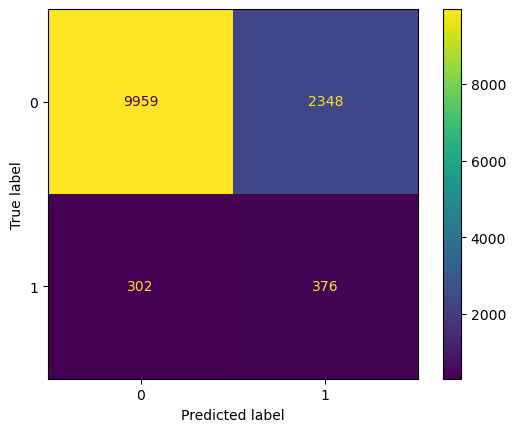

In [9]:
columns=len(X_train_scaled.columns)
X_train_scaled['calc_value']=X_train_scaled.apply(lambda row: row[0], axis =1)
j=0
while j < columns-2:
  X_train_scaled['calc_value']=X_train_scaled.apply(lambda row: classification(row['calc_value'], row[j+1], best_fold_result['a'], best_fold_result['kappa'], best_fold_result['lambda'], best_fold_result['gamma']), axis = 1)
  j += 1
X_train_scaled['calc_value_class'] = X_train_scaled.apply(lambda row: 0 if (row['calc_value']<= best_fold_result['a'])else 1, axis=1)
X_train_scaled['target_class'] = X_train_scaled.apply(lambda row: 0 if (row['target']<= best_fold_result['a'])else 1, axis=1)
calculate_tests(X_train_scaled[["calc_value_class"]].values, X_train_scaled[['target_class']].values)

In [10]:
columns=len(X_test_scaled.columns)
X_test_scaled['calc_value']=X_test_scaled.apply(lambda row: row[0], axis =1)
j=0
while j < columns-2:
  X_test_scaled['calc_value']=X_test_scaled.apply(lambda row: classification(row['calc_value'], row[j+1], best_fold_result['a'], best_fold_result['kappa'], best_fold_result['lambda'], best_fold_result['gamma']), axis = 1)
  j += 1
show_results(X_test_scaled, 0, 0, 0, 0, 0)

Results:
      HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0     0.705882  0.486354   0.774575    0.307111  0.938105  0.143464   
1     0.392157  0.292682   0.148185    0.223411  0.421939  0.729012   
2     0.156863  0.768556   0.170057    0.213027  0.712128  0.596174   
3     0.607843  0.552654   0.533404    0.463814  0.680022  0.148778   
4     0.156863  0.889251   0.536473    0.677470  0.494368  0.209352   
...        ...       ...        ...         ...       ...       ...   
3242  0.411765  0.705923   0.856468    0.337004  0.778447  0.404888   
3243  0.274510  0.548909   0.600250    0.492763  0.408587  0.471838   
3244  0.235294  0.605332   0.203404    0.426683  0.434468  0.848034   
3245  0.509804  0.518869   0.582547    0.910636  0.372683  0.170032   
3246  0.647059  0.647560   0.383651    0.263688  0.413177  0.133900   

      Longitude    MedInc    target  calc_value  
0      0.637771  0.367838  0.302377    0.539024  
1      0.092879  0.137319  0.119973   

In [11]:
X_test_scaled['target_class'] = X_test_scaled.apply(lambda row: 0 if (row['target']<= best_fold_result['a'])else 1, axis=1)
X_test_scaled['calc_value_class'] = X_test_scaled.apply(lambda row: 0 if (row['calc_value']<= best_fold_result['a'])else 1, axis=1)

In [12]:
target_values = X_test_scaled[['target_class']].values
value = X_test_scaled[['calc_value_class']].values

Accuracy score =  0.7991992608561749
F1 =  0.551515536687258
Precision =  0.6789485963138657
Recall =  0.5534872098834304


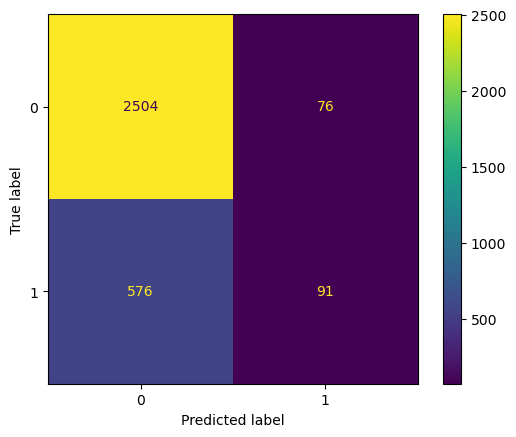

In [13]:
calculate_tests(target_values, value)